In [1]:
!pip install ultralytics
!pip install torch torchvision
!pip install roboflow
!pip install opencv-python-headless matplotlib
!wget "https://github.com/Li-Chongyi/Zero-DCE/raw/master/Zero-DCE_code/snapshots/Epoch99.pth" -O zerodce_weights.pth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 79.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13
--2026-04-30 02:49:51--  https://github.com/Li-Chongyi/Zero-DCE/raw/master/Zero-DCE_code/snapshots/Epoch99.pth
Resolving github.com (github.com)... 140.82.116.3
Co

In [2]:
# Cell 1 — Set up Kaggle credentials
import os
os.environ['KAGGLE_USERNAME'] = 'YOUR_KAGGLE_USERNAME'  # replace with yours
os.environ['KAGGLE_KEY'] = 'YOUR_KAGGLE_KEY'            # replace with yours

# Cell 2 — Download ExDark
!pip install kaggle
!kaggle datasets download -d washingtongold/exdark-dataset
!unzip exdark-dataset.zip -d exdark/

Streaming output truncated to the last 5000 lines.
  inflating: exdark/Bus/2015_02364.jpg  
  inflating: exdark/Bus/2015_02365.jpg  
  inflating: exdark/Bus/2015_02366.jpg  
  inflating: exdark/Bus/2015_02367.jpg  
  inflating: exdark/Bus/2015_02368.jpg  
  inflating: exdark/Bus/2015_02369.jpg  
  inflating: exdark/Bus/2015_02370.jpg  
  inflating: exdark/Bus/2015_02371.jpg  
  inflating: exdark/Bus/2015_02372.jpg  
  inflating: exdark/Bus/2015_02373.jpg  
  inflating: exdark/Bus/2015_02374.jpg  
  inflating: exdark/Bus/2015_02375.jpg  
  inflating: exdark/Bus/2015_02376.jpg  
  inflating: exdark/Bus/2015_02377.jpg  
  inflating: exdark/Bus/2015_02378.jpg  
  inflating: exdark/Bus/2015_02379.jpg  
  inflating: exdark/Bus/2015_02380.jpg  
  inflating: exdark/Bus/2015_02381.jpg  
  inflating: exdark/Bus/2015_02382.jpg  
  inflating: exdark/Bus/2015_02383.jpg  
  inflating: exdark/Bus/2015_02384.jpg  
  inflating: exdark/Bus/2015_02385.jpg  
  inflating: exdark/Bus/2015_02386.jpg  
  infl

Experiment 1 — Why dark images fail (Bullet 1)

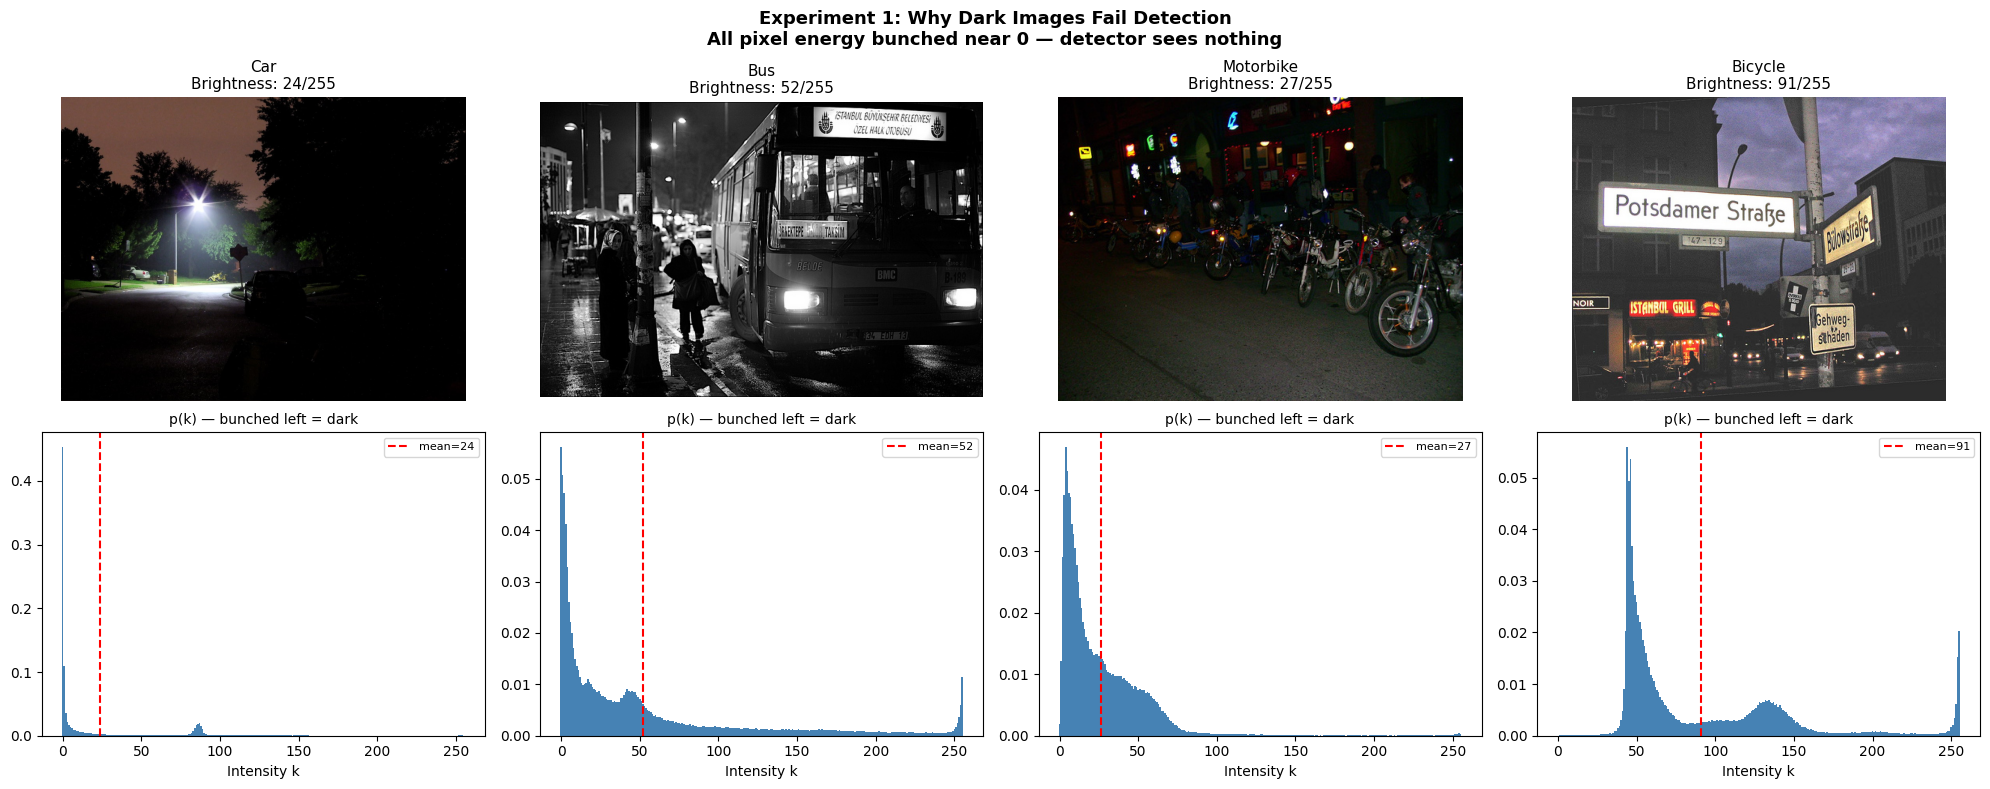

In [3]:
import cv2, numpy as np, matplotlib.pyplot as plt, glob, random

# Load 4 random dark vehicle images
vehicle_paths = []
for folder in ["Car", "Bus", "Motorbike", "Bicycle"]:
    paths = glob.glob(f"exdark/{folder}/*.*")
    vehicle_paths.extend(random.sample(paths, min(1, len(paths))))

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for col, path in enumerate(vehicle_paths[:4]):
    img     = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    axes[0][col].imshow(img_rgb)
    axes[0][col].set_title(f"{path.split('/')[-2]}\nBrightness: {gray.mean():.0f}/255", fontsize=11)
    axes[0][col].axis("off")

    hist, _ = np.histogram(gray.flatten(), bins=256, range=(0,255))
    axes[1][col].bar(range(256), hist/gray.size, color="steelblue", width=1)
    axes[1][col].set_title("p(k) — bunched left = dark", fontsize=10)
    axes[1][col].set_xlabel("Intensity k")
    axes[1][col].axvline(x=gray.mean(), color="red", linestyle="--",
                         label=f"mean={gray.mean():.0f}")
    axes[1][col].legend(fontsize=8)

plt.suptitle("Experiment 1: Why Dark Images Fail Detection\nAll pixel energy bunched near 0 — detector sees nothing",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("exp1_dark_images.png", dpi=150, bbox_inches="tight")
plt.show()

Experiment 2 — YOLOv8n model study (Bullet 2)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8n (nano): 645ms | 1 vehicles | params: 3.2M
YOLOv8s (small): 733ms | 1 vehicles | params: 11.2M


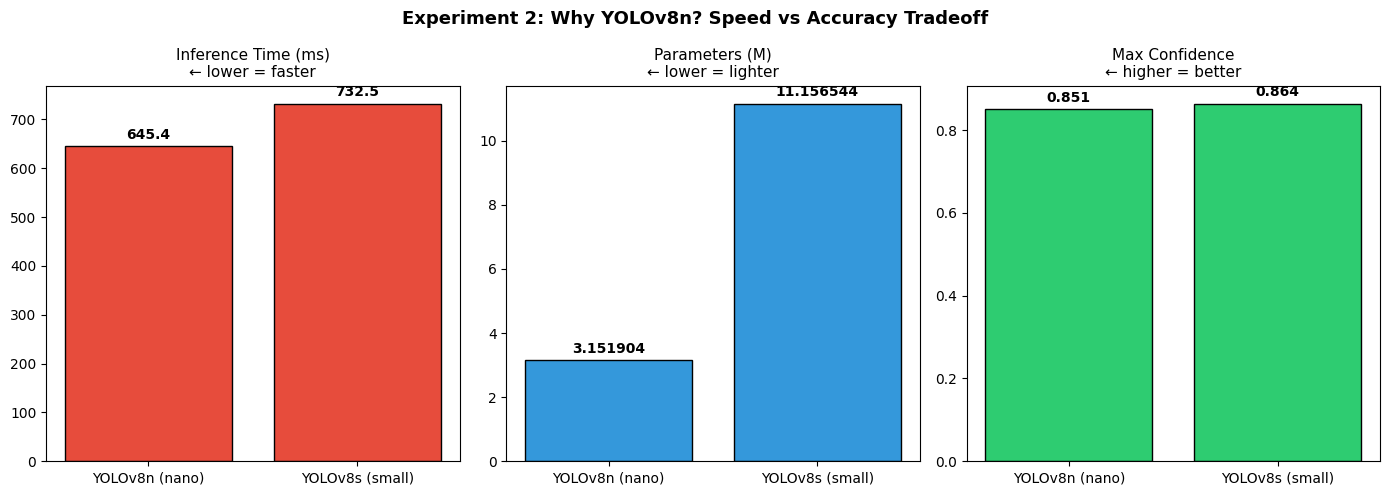

In [4]:
from ultralytics import YOLO
import time

# Compare YOLOv8 model sizes on same dark image
models_to_test = {
    "YOLOv8n (nano)":  "yolov8n.pt",   # smallest — best for real-time
    "YOLOv8s (small)": "yolov8s.pt",   # slightly bigger
}

img_path = "exdark/Car/2015_02891.jpg"
results_summary = {}

for name, weights in models_to_test.items():
    m = YOLO(weights)
    start = time.time()
    r = m(img_path, verbose=False)
    elapsed = time.time() - start

    detections = [float(b.conf[0]) for b in r[0].boxes if int(b.cls[0]) in [1,2,3,5,7]]
    results_summary[name] = {
        "time_ms":    round(elapsed * 1000, 1),
        "detections": len(detections),
        "max_conf":   round(max(detections), 3) if detections else 0,
        "params_M":   sum(p.numel() for p in m.model.parameters()) / 1e6
    }
    print(f"{name}: {elapsed*1000:.0f}ms | {len(detections)} vehicles | params: {results_summary[name]['params_M']:.1f}M")

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
names  = list(results_summary.keys())
times  = [results_summary[n]["time_ms"]  for n in names]
params = [results_summary[n]["params_M"] for n in names]
confs  = [results_summary[n]["max_conf"] for n in names]

for ax, vals, title, color in zip(
    axes,
    [times, params, confs],
    ["Inference Time (ms)\n← lower = faster", "Parameters (M)\n← lower = lighter", "Max Confidence\n← higher = better"],
    ["#e74c3c", "#3498db", "#2ecc71"]
):
    ax.bar(names, vals, color=color, edgecolor="black")
    ax.set_title(title, fontsize=11)
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals)*0.02, str(v), ha="center", fontweight="bold")

plt.suptitle("Experiment 2: Why YOLOv8n? Speed vs Accuracy Tradeoff",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("exp2_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

ExDark dataset analysis

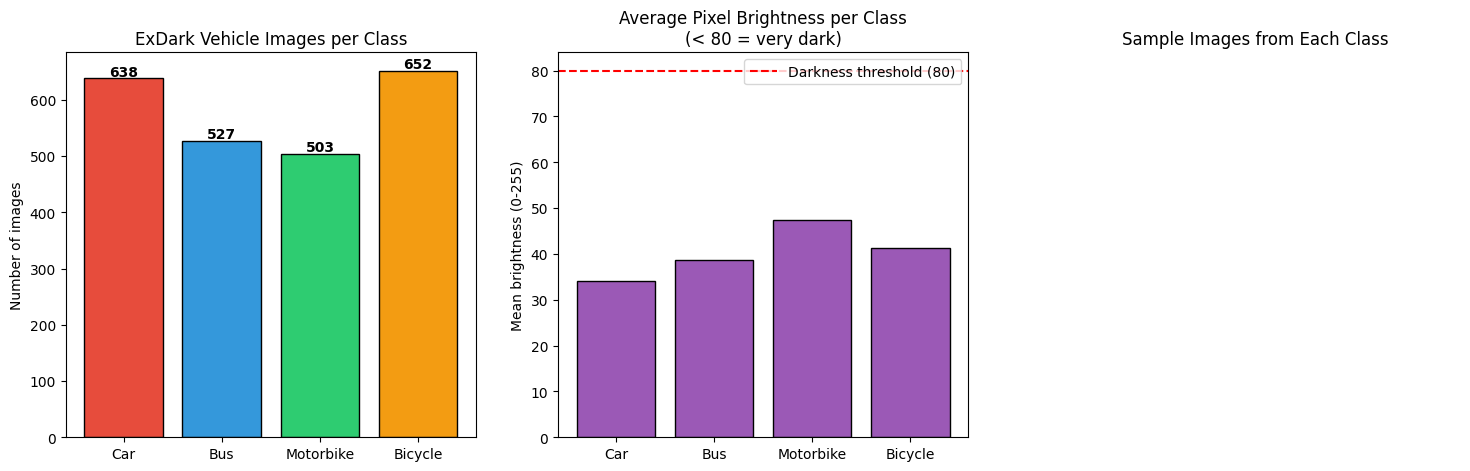

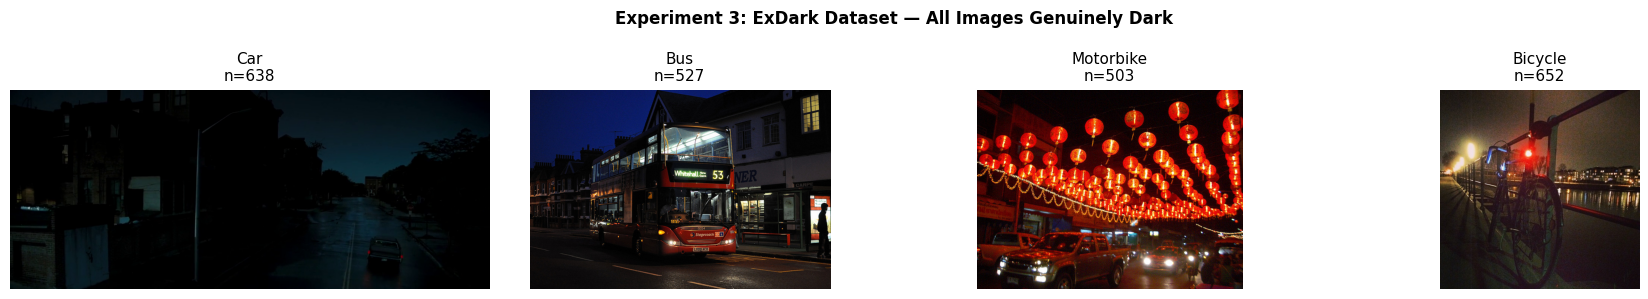


EXDARK VEHICLE SUMMARY:
Class          Images   Avg Brightness
--------------------------------------
Car               638           34.1
Bus               527           38.7
Motorbike         503           47.4
Bicycle           652           41.3

Total vehicle images: 2320


In [5]:
import os, glob
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2, numpy as np

# Count images per vehicle class
VEHICLE_CLASSES = ["Car", "Bus", "Motorbike", "Bicycle"]
counts = {}
avg_brightness = {}

for cls in VEHICLE_CLASSES:
    paths = glob.glob(f"exdark/{cls}/*.*")
    counts[cls] = len(paths)
    brightnesses = []
    for p in random.sample(paths, min(30, len(paths))):
        img  = cv2.imread(p)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brightnesses.append(gray.mean())
    avg_brightness[cls] = np.mean(brightnesses)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart — image counts
axes[0].bar(counts.keys(), counts.values(),
            color=["#e74c3c","#3498db","#2ecc71","#f39c12"], edgecolor="black")
axes[0].set_title("ExDark Vehicle Images per Class", fontsize=12)
axes[0].set_ylabel("Number of images")
for i, (cls, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt+5, str(cnt), ha="center", fontweight="bold")

# Brightness per class — proves images are genuinely dark
axes[1].bar(avg_brightness.keys(), avg_brightness.values(),
            color="#9b59b6", edgecolor="black")
axes[1].axhline(y=80, color="red", linestyle="--", label="Darkness threshold (80)")
axes[1].set_title("Average Pixel Brightness per Class\n(< 80 = very dark)", fontsize=12)
axes[1].set_ylabel("Mean brightness (0-255)")
axes[1].legend()

# Show one sample from each class
sample_imgs = []
for cls in VEHICLE_CLASSES:
    p = glob.glob(f"exdark/{cls}/*.*")[0]
    img = cv2.imread(p)
    sample_imgs.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

axes[2].axis("off")
axes[2].set_title("Sample Images from Each Class", fontsize=12)

# Mini grid inside axes[2]
fig2, ax2 = plt.subplots(1, 4, figsize=(18, 3))
for i, (cls, img) in enumerate(zip(VEHICLE_CLASSES, sample_imgs)):
    ax2[i].imshow(img)
    ax2[i].set_title(f"{cls}\nn={counts[cls]}", fontsize=11)
    ax2[i].axis("off")
fig2.suptitle("Experiment 3: ExDark Dataset — All Images Genuinely Dark",
              fontsize=12, fontweight="bold")
fig2.tight_layout()
fig2.savefig("exp3_dataset_analysis.png", dpi=150, bbox_inches="tight")
fig2.show()

plt.tight_layout()
plt.savefig("exp3_counts.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nEXDARK VEHICLE SUMMARY:")
print(f"{'Class':12s} {'Images':>8} {'Avg Brightness':>16}")
print("-" * 38)
for cls in VEHICLE_CLASSES:
    print(f"{cls:12s} {counts[cls]:>8} {avg_brightness[cls]:>14.1f}")
print(f"\nTotal vehicle images: {sum(counts.values())}")

In [6]:
# Download real Zero-DCE weights
!wget "https://github.com/Li-Chongyi/Zero-DCE/raw/master/Zero-DCE_code/snapshots/Epoch99.pth" -O zerodce_weights.pth

# Verify
import os
print(f"Downloaded: {os.path.getsize('zerodce_weights.pth')/1024:.0f} KB")
# Should print ~312 KB

--2026-04-30 02:51:32--  https://github.com/Li-Chongyi/Zero-DCE/raw/master/Zero-DCE_code/snapshots/Epoch99.pth
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Li-Chongyi/Zero-DCE/master/Zero-DCE_code/snapshots/Epoch99.pth [following]
--2026-04-30 02:51:33--  https://raw.githubusercontent.com/Li-Chongyi/Zero-DCE/master/Zero-DCE_code/snapshots/Epoch99.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 320017 (313K) [application/octet-stream]
Saving to: ‘zerodce_weights.pth’

zerodce_weights.pth 100%[===================>] 312.52K  --.-KB/s    in 0.02s   

2026-04-30 02:51:33 (16.4 MB/s) - ‘zerodce

Experiment 4 — CLAHE vs Zero-DCE comparison (Bullet 4)



ZeroDCE ready on cpu


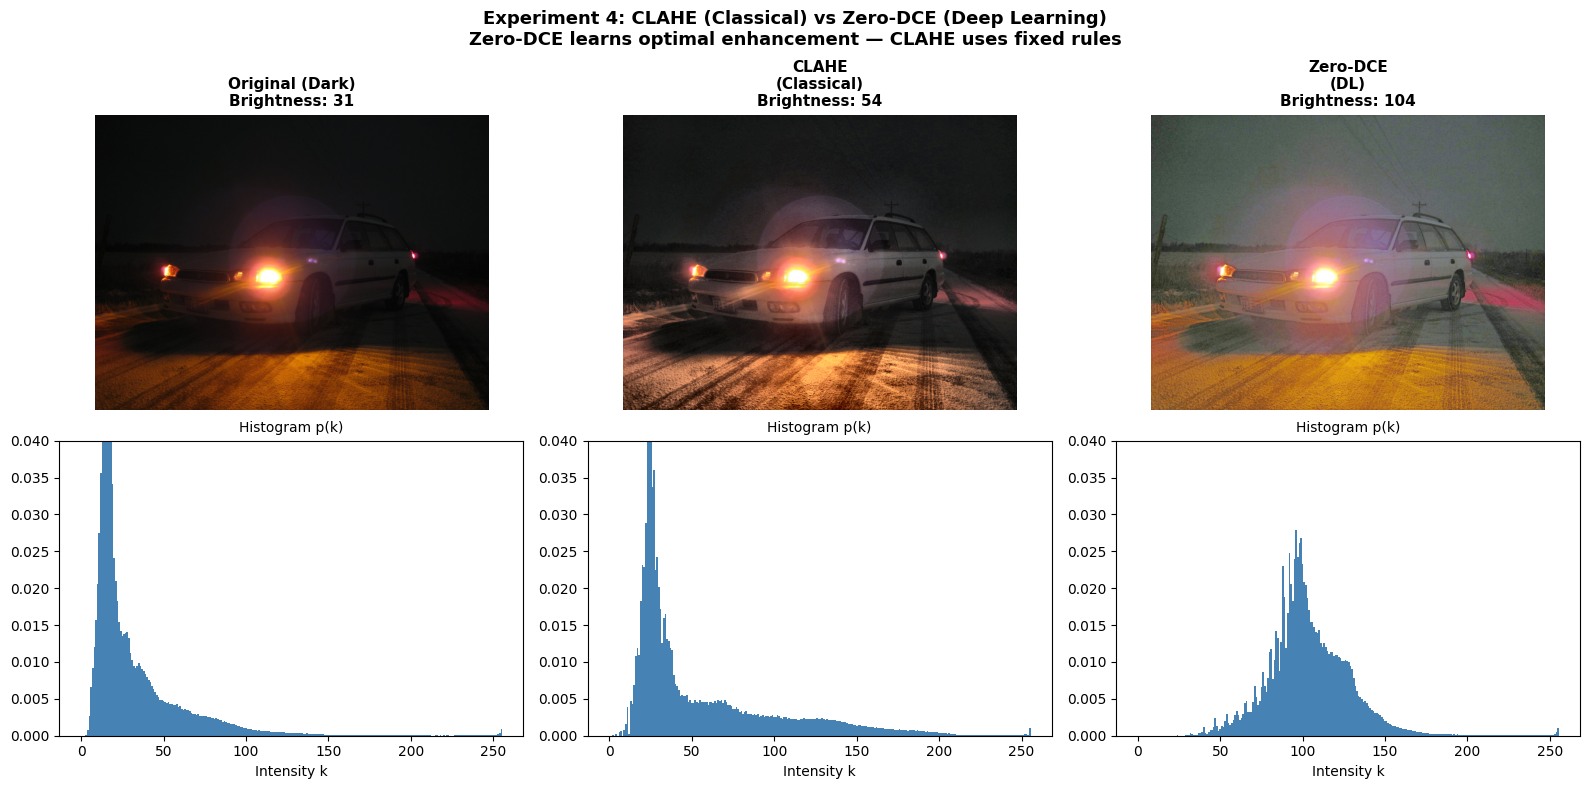


DETECTION CONFIDENCE COMPARISON:
Method                 Detections   Max Confidence
--------------------------------------------------
Original                        1            0.851
CLAHE                           1            0.829
Zero-DCE                        1            0.697


In [7]:
import torch, torch.nn as nn
from PIL import Image
import torchvision.transforms as transforms
import cv2, numpy as np
from ultralytics import YOLO



class ZeroDCE(nn.Module):
    def __init__(self):
        super(ZeroDCE, self).__init__()
        self.relu    = nn.ReLU(inplace=True)
        self.e_conv1 = nn.Conv2d(3,32,3,1,1,bias=True)
        self.e_conv2 = nn.Conv2d(32,32,3,1,1,bias=True)
        self.e_conv3 = nn.Conv2d(32,32,3,1,1,bias=True)
        self.e_conv4 = nn.Conv2d(32,32,3,1,1,bias=True)
        self.e_conv5 = nn.Conv2d(64,32,3,1,1,bias=True)
        self.e_conv6 = nn.Conv2d(64,32,3,1,1,bias=True)
        self.e_conv7 = nn.Conv2d(64,24,3,1,1,bias=True)
        self.tanh    = nn.Tanh()

    def forward(self, x):
        x1 = self.relu(self.e_conv1(x))
        x2 = self.relu(self.e_conv2(x1))
        x3 = self.relu(self.e_conv3(x2))
        x4 = self.relu(self.e_conv4(x3))
        x5 = self.relu(self.e_conv5(torch.cat([x3,x4],1)))
        x6 = self.relu(self.e_conv6(torch.cat([x2,x5],1)))
        x_r = self.tanh(self.e_conv7(torch.cat([x1,x6],1)))
        r1,r2,r3,r4,r5,r6,r7,r8 = torch.split(x_r,3,dim=1)
        x = x+r1*(torch.pow(x,2)-x)
        x = x+r2*(torch.pow(x,2)-x)
        x = x+r3*(torch.pow(x,2)-x)
        x = x+r4*(torch.pow(x,2)-x)
        x = x+r5*(torch.pow(x,2)-x)
        x = x+r6*(torch.pow(x,2)-x)
        x = x+r7*(torch.pow(x,2)-x)
        x = x+r8*(torch.pow(x,2)-x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
zerodce = ZeroDCE().to(device)
zerodce.load_state_dict(torch.load("zerodce_weights.pth", map_location=device))
zerodce.eval()
print("ZeroDCE ready on", device)

# ── Real Zero-DCE function ─────────────────────────────
def enhance_image_zerodce(image_input):
    if isinstance(image_input, str):
        img = Image.open(image_input).convert("RGB")
    else:
        img = Image.fromarray(cv2.cvtColor(image_input, cv2.COLOR_BGR2RGB))
    t = transforms.ToTensor()(img).unsqueeze(0).to(device)
    with torch.no_grad():
        out = zerodce(t)
    out_np = out.squeeze(0).cpu().numpy().transpose(1,2,0)
    out_np = np.clip(out_np, 0, 1)
    return cv2.cvtColor((out_np*255).astype(np.uint8), cv2.COLOR_RGB2BGR)

def apply_clahe(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l_enhanced, a, b)), cv2.COLOR_LAB2BGR)

# ── Experiment 4 — CLAHE vs Zero-DCE ──────────────────
img_bgr  = cv2.imread("exdark/Car/2015_02891.jpg")
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
clahe_bgr = apply_clahe(img_bgr)
clahe_rgb = cv2.cvtColor(clahe_bgr, cv2.COLOR_BGR2RGB)
zdce_bgr  = enhance_image_zerodce("exdark/Car/2015_02891.jpg")
zdce_rgb  = cv2.cvtColor(zdce_bgr, cv2.COLOR_BGR2RGB)

methods = {
    "Original (Dark)":    img_rgb,
    "CLAHE\n(Classical)": clahe_rgb,
    "Zero-DCE\n(DL)":     zdce_rgb,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for col, (title, img) in enumerate(methods.items()):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    axes[0][col].imshow(img)
    axes[0][col].set_title(f"{title}\nBrightness: {gray.mean():.0f}", fontsize=11, fontweight="bold")
    axes[0][col].axis("off")
    hist, _ = np.histogram(gray.flatten(), bins=256, range=(0,255))
    axes[1][col].bar(range(256), hist/gray.size, color="steelblue", width=1)
    axes[1][col].set_title("Histogram p(k)", fontsize=10)
    axes[1][col].set_xlabel("Intensity k")
    axes[1][col].set_ylim(0, 0.04)

plt.suptitle("Experiment 4: CLAHE (Classical) vs Zero-DCE (Deep Learning)\nZero-DCE learns optimal enhancement — CLAHE uses fixed rules",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("exp4_clahe_vs_zerodce.png", dpi=150, bbox_inches="tight")
plt.show()

model = YOLO("yolov8n.pt")
VEHICLE_CLASSES = {1:"bicycle",2:"car",3:"motorcycle",5:"bus",7:"truck"}

print("\nDETECTION CONFIDENCE COMPARISON:")
print(f"{'Method':20s} {'Detections':>12} {'Max Confidence':>16}")
print("-"*50)
for title, inp in [("Original", img_bgr), ("CLAHE", clahe_bgr), ("Zero-DCE", zdce_bgr)]:
    r    = model(inp, verbose=False)
    dets = [float(b.conf[0]) for b in r[0].boxes if int(b.cls[0]) in VEHICLE_CLASSES]
    print(f"{title:20s} {len(dets):>12} {max(dets) if dets else 0:>16.3f}")

Experiment 5 — Confidence score as evaluation metric (Bullet 5)


In [8]:
# Run across 50 images to show confidence improvement statistically
import random, numpy as np

VEHICLE_FOLDERS = ["Car", "Bus", "Motorbike", "Bicycle"]
model = YOLO("yolov8n.pt")
VEHICLE_IDS = {1,2,3,5,7}

all_paths = []
for f in VEHICLE_FOLDERS:
    paths = glob.glob(f"exdark/{f}/*.*")
    all_paths.extend(random.sample(paths, min(15, len(paths))))

print(f"Testing on {len(all_paths)} images...")

orig_confs, zdce_confs, clahe_confs = [], [], []
rescued_by_zdce = 0
THRESHOLD = 0.4

for i, path in enumerate(all_paths):
    img = cv2.imread(path)
    if img is None: continue

    zdce = enhance_image_zerodce(path)
    clh  = apply_clahe(img)

    def get_max_conf(inp):
        r    = model(inp, verbose=False)
        dets = [float(b.conf[0]) for b in r[0].boxes if int(b.cls[0]) in VEHICLE_IDS]
        return max(dets) if dets else 0.0

    o = get_max_conf(img)
    z = get_max_conf(zdce)
    c = get_max_conf(clh)

    orig_confs.append(o)
    zdce_confs.append(z)
    clahe_confs.append(c)

    if o < THRESHOLD and z >= THRESHOLD:
        rescued_by_zdce += 1

    if (i+1) % 10 == 0:
        print(f"  Processed {i+1}/{len(all_paths)}...")

# Summary stats
print(f"\n{'='*50}")
print(f"RESULTS ACROSS {len(orig_confs)} IMAGES")
print(f"{'='*50}")
print(f"{'Method':20s} {'Avg Conf':>10} {'Median':>10} {'>0.5 rate':>12}")
print("-"*50)
for name, confs in [("Original (Dark)", orig_confs),
                    ("CLAHE",           clahe_confs),
                    ("Zero-DCE",        zdce_confs)]:
    arr = np.array(confs)
    print(f"{name:20s} {arr.mean():>10.3f} {np.median(arr):>10.3f} {(arr>0.5).mean()*100:>10.1f}%")

print(f"\nImages rescued by Zero-DCE (was <{THRESHOLD}, now ≥{THRESHOLD}): {rescued_by_zdce}/{len(orig_confs)}")

# Final bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = ["Original\n(Dark)", "CLAHE\n(Classical)", "Zero-DCE\n(Deep Learning)"]
avgs    = [np.mean(orig_confs), np.mean(clahe_confs), np.mean(zdce_confs)]
colors  = ["#c0392b", "#f39c12", "#27ae60"]

bars = axes[0].bar(methods, avgs, color=colors, edgecolor="black", width=0.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("Average Detection Confidence", fontsize=12)
axes[0].set_title("Average Confidence Across All Test Images", fontsize=12)
for bar, val in zip(bars, avgs):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.02,
                 f"{val:.3f}", ha="center", fontsize=12, fontweight="bold")

# Box plot shows full distribution
axes[1].boxplot([orig_confs, clahe_confs, zdce_confs],
                labels=["Original", "CLAHE", "Zero-DCE"],
                patch_artist=True,
                boxprops=dict(facecolor="#3498db", alpha=0.6))
axes[1].set_ylabel("Confidence Score", fontsize=12)
axes[1].set_title("Confidence Distribution\n(higher median = better)", fontsize=12)
axes[1].axhline(y=0.5, color="red", linestyle="--", label="Detection threshold 0.5")
axes[1].legend()

plt.suptitle("Experiment 5: Does Enhancement Improve Detection?\nConfidence Score as Evaluation Metric",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("exp5_confidence_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Testing on 60 images...


KeyboardInterrupt: 

In [ ]:
import glob, random, numpy as np, matplotlib.pyplot as plt

random.seed(42)
VEHICLE_IDS = {1, 2, 3, 5, 7}

# build val_images from exdark/ directly
all_paths = []
for folder in ["Car", "Bus", "Motorbike", "Bicycle"]:
    paths = glob.glob(f"exdark/{folder}/*.*")
    all_paths.extend(random.sample(paths, min(8, len(paths))))
val_images = all_paths
print(f"Using {len(val_images)} images from exdark/")

def evaluate_pipeline(image_paths, label="", enhance_fn=None):
    all_confs = []
    for img_path in image_paths:
        inp = enhance_fn(img_path) if enhance_fn else img_path
        results = model(inp, verbose=False)
        for box in results[0].boxes:
            if int(box.cls[0]) in VEHICLE_IDS:
                all_confs.append(float(box.conf[0]))
    avg = np.mean(all_confs) if all_confs else 0
    print(f"  [{label}] detections: {len(all_confs)} | avg confidence: {avg:.3f}")
    return avg, len(all_confs)

print("Running Plain YOLO...")
avg_plain, count_plain = evaluate_pipeline(val_images, "YOLO only")

print("Running Zero-DCE + YOLO...")
avg_dce, count_dce = evaluate_pipeline(val_images, "Zero-DCE + YOLO",
                                        enhance_fn=enhance_image_zerodce)

# plot
labels = ["YOLO only", "Zero-DCE\n+ YOLO"]
confs  = [avg_plain, avg_dce]
counts = [count_plain, count_dce]
colors = ["#c0392b", "#27ae60"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

b1 = ax1.bar(labels, confs, color=colors, width=0.4, edgecolor="black")
ax1.set_ylim(0, 1.0)
ax1.set_ylabel("Avg Detection Confidence")
ax1.set_title("Confidence: YOLO vs Zero-DCE + YOLO")
for bar, val in zip(b1, confs):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f"{val:.3f}", ha="center", fontweight="bold")

b2 = ax2.bar(labels, counts, color=colors, width=0.4, edgecolor="black")
ax2.set_ylabel("Total Detections")
ax2.set_title("Detection Count: YOLO vs Zero-DCE + YOLO")
for bar, val in zip(b2, counts):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             str(val), ha="center", fontweight="bold")

plt.suptitle("Pipeline Comparison: Zero-DCE + YOLO vs Baseline YOLO", fontsize=12)
plt.tight_layout()
plt.savefig("pipeline_comparison.png", dpi=150)
plt.show()

print(f"\n{'Pipeline':<20} {'Avg Conf':>10} {'Detections':>12}")
print("─" * 44)
for l, c, d in zip(labels, confs, counts):
    tag = " ← better" if c == max(confs) else ""
    print(f"{l:<20} {c:>10.3f} {d:>12}{tag}")

Using 32 images from exdark/
Running Plain YOLO...
  [YOLO only] detections: 83 | avg confidence: 0.596
Running Zero-DCE + YOLO...
